В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [511]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [512]:
whole_train_df = pd.read_csv("train.csv")
whole_train_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


In [513]:
whole_train_df.Exited.value_counts()

Exited
0.0    11948
1.0     3052
Name: count, dtype: int64

Маємо дисбаланс класів, а отже варто використати стратіфаєр при розбитті датафрейму.

In [514]:
train_df, val_df = train_test_split(whole_train_df,
                                    test_size=0.25,
                                    random_state=3,
                                    stratify=whole_train_df.Exited)

train_df.Exited.value_counts(), val_df.Exited.value_counts()

(Exited
 0.0    8961
 1.0    2289
 Name: count, dtype: int64,
 Exited
 0.0    2987
 1.0     763
 Name: count, dtype: int64)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [515]:
input_cols = train_df.columns[1:-1]
target_col = "Exited"

input_cols

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary'],
      dtype='object')

In [516]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

print("Train:", train_inputs.shape, train_targets.shape)
print("Validate:", val_inputs.shape, val_targets.shape)

Train: (11250, 12) (11250,)
Validate: (3750, 12) (3750,)


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [517]:
numeric_cols = train_inputs.select_dtypes("number").columns.to_list()
categorical_cols = train_inputs.select_dtypes("object").columns.to_list()

numeric_cols, categorical_cols

(['CustomerId',
  'CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

**1. Перевіримо наявність пропущених значень у тест і валідейшн наборах.**

In [518]:
# Check for null (missed) values in train
train_inputs.info()
train_targets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 8974 to 12225
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       11250 non-null  float64
 1   Surname          11250 non-null  object 
 2   CreditScore      11250 non-null  float64
 3   Geography        11250 non-null  object 
 4   Gender           11250 non-null  object 
 5   Age              11250 non-null  float64
 6   Tenure           11250 non-null  float64
 7   Balance          11250 non-null  float64
 8   NumOfProducts    11250 non-null  float64
 9   HasCrCard        11250 non-null  float64
 10  IsActiveMember   11250 non-null  float64
 11  EstimatedSalary  11250 non-null  float64
dtypes: float64(9), object(3)
memory usage: 1.1+ MB
<class 'pandas.core.series.Series'>
Index: 11250 entries, 8974 to 12225
Series name: Exited
Non-Null Count  Dtype  
--------------  -----  
11250 non-null  float64
dtypes: float64(1)
memory usage: 

In [519]:
# Check for null (missed) values in validation
val_inputs.info()
val_targets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3750 entries, 12957 to 9899
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       3750 non-null   float64
 1   Surname          3750 non-null   object 
 2   CreditScore      3750 non-null   float64
 3   Geography        3750 non-null   object 
 4   Gender           3750 non-null   object 
 5   Age              3750 non-null   float64
 6   Tenure           3750 non-null   float64
 7   Balance          3750 non-null   float64
 8   NumOfProducts    3750 non-null   float64
 9   HasCrCard        3750 non-null   float64
 10  IsActiveMember   3750 non-null   float64
 11  EstimatedSalary  3750 non-null   float64
dtypes: float64(9), object(3)
memory usage: 380.9+ KB
<class 'pandas.core.series.Series'>
Index: 3750 entries, 12957 to 9899
Series name: Exited
Non-Null Count  Dtype  
--------------  -----  
3750 non-null   float64
dtypes: float64(1)
memory usage: 

**Висновок.** Як видно, пропущених значень немає.

**2. Масштабування числових колонок**

Масштабуємо числові колонки, щоб при тренуванні моделі бачити реальний вплив кожної з них на таргет.

In [520]:
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

display(train_inputs.head()), display(val_inputs.head())

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
8974,0.986116,Galkin,0.591885,France,Male,0.481481,0.4,0.000000,0.000000,1.0,0.0,0.409405
5022,0.989714,Gentry,0.529833,France,Female,0.518519,0.6,0.788143,0.000000,1.0,0.0,0.517846
10702,0.995470,Hsu,0.334129,France,Female,0.277778,0.8,0.000000,0.333333,1.0,0.0,0.552024
8242,0.994610,O'Brien,0.725537,Spain,Male,0.481481,0.6,0.000000,0.000000,1.0,0.0,0.879294
12900,0.984340,Nwankwo,0.649165,France,Female,0.148148,0.4,0.000000,0.333333,1.0,1.0,0.794887


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
12957,0.998473,Chien,0.670644,France,Female,0.277778,0.3,0.57743,0.000000,0.0,1.0,0.259964
9119,0.984095,Hs?,0.634845,France,Male,0.370370,0.8,0.00000,0.333333,1.0,1.0,0.939115
10137,0.985554,Crawford,0.718377,France,Female,0.333333,0.8,0.00000,0.333333,1.0,1.0,0.328800
5904,0.990470,Tuan,0.749403,Spain,Male,0.444444,0.6,0.00000,0.000000,1.0,1.0,0.714204
7848,0.990882,Ku,0.732697,France,Male,0.388889,0.7,0.00000,0.000000,1.0,0.0,0.374232


(None, None)

**3. Дослідження і перетворення категоріальних колонок**

Трансформуємо категоріальні колонки у числові, щоб модель могла з ними працювати.

In [521]:
# Check value counts for all categorial columns
for column in categorical_cols:
    print(train_inputs[column].value_counts(), "\n")
    print("-------\n")

Surname
Ch'iu       193
Ch'ang      183
Ch'ien      174
Hsia        161
T'ien       139
           ... 
Trentini      1
Istomin       1
McEwan        1
Kisch         1
Ozuoke        1
Name: count, Length: 724, dtype: int64 

-------

Geography
France     6826
Spain      2481
Germany    1943
Name: count, dtype: int64 

-------

Gender
Male      6437
Female    4813
Name: count, dtype: int64 

-------



**Висновок.** Колонка `Gender` - бінарна, а `Geography` має 3 значення. Закодуємо їх за допомогою OneHotEncoder, причому бінарну - однією колонкою. `Surname` має аж 724 значення. Теоретично її можна було б теж закодувати OneHotEcoder-ом, бо ми маємо 11250 записів у трейн сеті, але тоді переважна більшість колонок відповідала б тільки за `Surname`. Тому ця колонка потребує додаткових досліджень. Поки просто видалимо її.

**Видалимо колонку `Surname`**

In [522]:
train_inputs.drop('Surname', axis=1, inplace=True)
val_inputs.drop('Surname', axis=1, inplace=True)
categorical_cols.remove('Surname')

**Закодуємо `Gender` і `Geography`**

In [523]:
oh_encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
oh_encoder.fit(train_inputs[categorical_cols])
encoded_cols = oh_encoder.get_feature_names_out(categorical_cols).tolist()

train_inputs[encoded_cols] = oh_encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = oh_encoder.transform(val_inputs[categorical_cols])

**Видалимо оригінальні категоріальні колонки**

In [524]:
train_inputs.drop(categorical_cols, axis=1, inplace=True)
val_inputs.drop(categorical_cols, axis=1, inplace=True)

In [525]:
display(train_inputs.head()), display(val_inputs.head())

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
8974,0.986116,0.591885,0.481481,0.4,0.000000,0.000000,1.0,0.0,0.409405,1.0,0.0,0.0,1.0
5022,0.989714,0.529833,0.518519,0.6,0.788143,0.000000,1.0,0.0,0.517846,1.0,0.0,0.0,0.0
10702,0.995470,0.334129,0.277778,0.8,0.000000,0.333333,1.0,0.0,0.552024,1.0,0.0,0.0,0.0
8242,0.994610,0.725537,0.481481,0.6,0.000000,0.000000,1.0,0.0,0.879294,0.0,0.0,1.0,1.0
12900,0.984340,0.649165,0.148148,0.4,0.000000,0.333333,1.0,1.0,0.794887,1.0,0.0,0.0,0.0


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
12957,0.998473,0.670644,0.277778,0.3,0.57743,0.000000,0.0,1.0,0.259964,1.0,0.0,0.0,0.0
9119,0.984095,0.634845,0.370370,0.8,0.00000,0.333333,1.0,1.0,0.939115,1.0,0.0,0.0,1.0
10137,0.985554,0.718377,0.333333,0.8,0.00000,0.333333,1.0,1.0,0.328800,1.0,0.0,0.0,0.0
5904,0.990470,0.749403,0.444444,0.6,0.00000,0.000000,1.0,1.0,0.714204,0.0,0.0,1.0,1.0
7848,0.990882,0.732697,0.388889,0.7,0.00000,0.000000,1.0,0.0,0.374232,1.0,0.0,0.0,1.0


(None, None)

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [526]:
train_inputs.to_parquet('kaggle_churn/train_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('kaggle_churn/train_targets.parquet')
val_inputs.to_parquet('kaggle_churn/val_inputs.parquet')
pd.DataFrame(val_targets).to_parquet('kaggle_churn/val_targets.parquet')

os.listdir('kaggle_churn')

['train_targets.parquet',
 'train_inputs.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [527]:
X_train = train_inputs
X_val = val_inputs

display(X_train.head()), display(X_val.head())

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
8974,0.986116,0.591885,0.481481,0.4,0.000000,0.000000,1.0,0.0,0.409405,1.0,0.0,0.0,1.0
5022,0.989714,0.529833,0.518519,0.6,0.788143,0.000000,1.0,0.0,0.517846,1.0,0.0,0.0,0.0
10702,0.995470,0.334129,0.277778,0.8,0.000000,0.333333,1.0,0.0,0.552024,1.0,0.0,0.0,0.0
8242,0.994610,0.725537,0.481481,0.6,0.000000,0.000000,1.0,0.0,0.879294,0.0,0.0,1.0,1.0
12900,0.984340,0.649165,0.148148,0.4,0.000000,0.333333,1.0,1.0,0.794887,1.0,0.0,0.0,0.0


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
12957,0.998473,0.670644,0.277778,0.3,0.57743,0.000000,0.0,1.0,0.259964,1.0,0.0,0.0,0.0
9119,0.984095,0.634845,0.370370,0.8,0.00000,0.333333,1.0,1.0,0.939115,1.0,0.0,0.0,1.0
10137,0.985554,0.718377,0.333333,0.8,0.00000,0.333333,1.0,1.0,0.328800,1.0,0.0,0.0,0.0
5904,0.990470,0.749403,0.444444,0.6,0.00000,0.000000,1.0,1.0,0.714204,0.0,0.0,1.0,1.0
7848,0.990882,0.732697,0.388889,0.7,0.00000,0.000000,1.0,0.0,0.374232,1.0,0.0,0.0,1.0


(None, None)

In [528]:
y_train = train_targets
y_val = val_targets

display(y_train.head()), display(y_val.head())

8974     1.0
5022     1.0
10702    0.0
8242     1.0
12900    0.0
Name: Exited, dtype: float64

12957    1.0
9119     0.0
10137    0.0
5904     0.0
7848     0.0
Name: Exited, dtype: float64

(None, None)

In [529]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [530]:
# Predict targets for train and validation sets
pred_train = model.predict(X_train)
pred_val = model.predict(X_val)

pred_train, pred_val

(array([0., 1., 0., ..., 0., 0., 0.], shape=(11250,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(3750,)))

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [531]:
def show_model_metrics(df_name, X, y, pred):
    cf = confusion_matrix(y, pred)
    cf_norm = confusion_matrix(y, pred, normalize='true')
    plt.figure()
    sns.heatmap(cf_norm, annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{df_name} Confusion Matrix')
    plt.show()

    probs = model.predict_proba(X)
    fpr, tpr, thresholds = roc_curve(y, probs[:, 1])
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel('fpr')
    plt.ylabel('tpr')
    plt.title(f"{df_name} ROC Curve")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.show()

    auc_roc = auc(fpr, tpr)
    f1 = f1_score(y, pred)

    return {
        'Set name': df_name,
        'Confusion matrix': cf,
        'AUROC': auc_roc,
        'F1 score': f1
    }

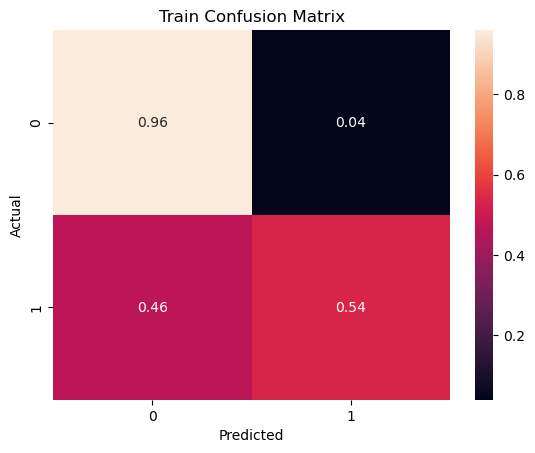

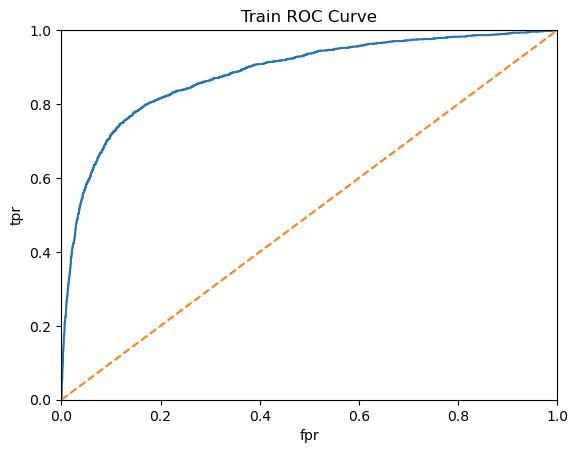

{'Set name': 'Train',
 'Confusion matrix': array([[8602,  359],
        [1063, 1226]]),
 'AUROC': 0.8820606005471308,
 'F1 score': 0.6329375322663914}

In [532]:
train_metrics = show_model_metrics('Train', X_train, y_train, pred_train)
train_metrics

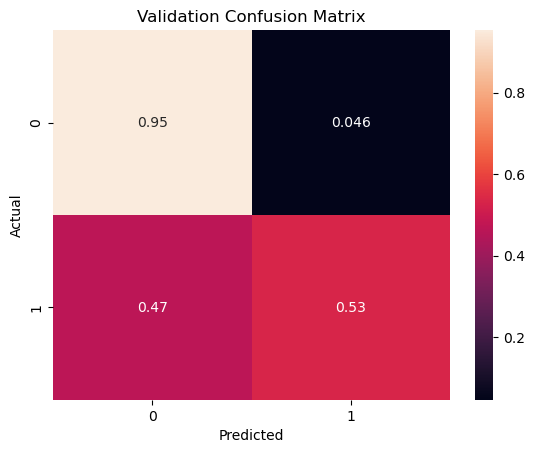

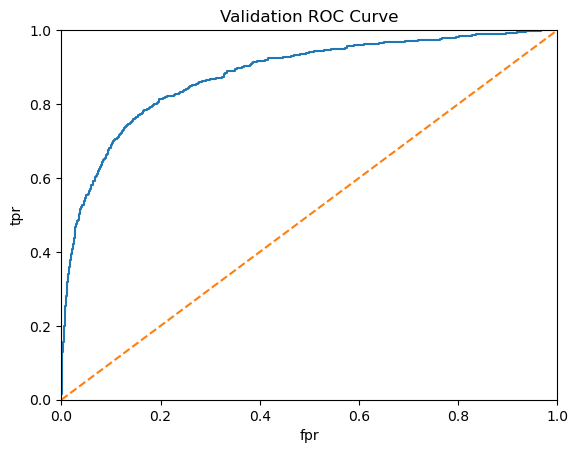

{'Set name': 'Validation',
 'Confusion matrix': array([[2849,  138],
        [ 355,  408]]),
 'AUROC': 0.8797098479606473,
 'F1 score': 0.6233766233766234}

In [533]:
val_metrics = show_model_metrics('Validation', X_val, y_val, pred_val)
val_metrics

**Висновки**
- Тренувальна і валідаційна моделі показують схожі метрики.
- Оцінка `AUROC` доволі хороша (0.88). `F1 score` задовільна (0.62) - це говорить про те, що можна обрати кращу границю, ніж за замовчуванням (0.5).
- Матриця невизначеності показує, що модель добре визначає клас 0 (95%), але пропускає майже половину класу 1 (53%). Це може бути викликано дисбалансом по кількості записів з класом 0 і 1. Можливо зміна границі покращить результати.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [534]:
# Check which class has more values
y_train.value_counts()

Exited
0.0    8961
1.0    2289
Name: count, dtype: int64

In [535]:
# Define function and use it to create all-zeroes predictions
def predict_all_zeroes(X):
    return np.full(len(X), 0.0)


pred_train_0 = predict_all_zeroes(X_train)
pred_val_0 = predict_all_zeroes(X_val)

pred_train_0.shape, pred_val_0.shape

((11250,), (3750,))

In [536]:
print('Accuracy')
print('For all zeroes on train:', accuracy_score(y_train, pred_train_0))
print('For all zeroes on validation:', accuracy_score(y_val, pred_val_0))
print('For model on train:', accuracy_score(y_train, pred_train))
print('For model on validation:', accuracy_score(y_val, pred_val))

Accuracy
For all zeroes on train: 0.7965333333333333
For all zeroes on validation: 0.7965333333333333
For model on train: 0.8736
For model on validation: 0.8685333333333334


**Висновок.** Модель, побудована вище, показує кращу точність, ніж та, що просто завжди передбачає більш поширений клас. Це ще не говорить про те, що вона добра, але вона працює.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [537]:
# Write into the file
log_reg = {
    'model': model,
    'scaler': scaler,
    'encoder': oh_encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(log_reg, 'log_reg.joblib')

['log_reg.joblib']

In [538]:
# Read model from file and check it
model_2 = joblib.load('log_reg.joblib')['model']

pred_val_2 = model.predict(X_val)
print('F1 score for model:', val_metrics['F1 score'])
print('F1 score for model_2:', f1_score(y_val, pred_val_2))

F1 score for model: 0.6233766233766234
F1 score for model_2: 0.6233766233766234


`F1 score` однакова, це підтверджує правильні запис-зчитування моделі.

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [539]:
def predict_raw_df(model, scaler, encoder,
                   numeric_cols, categorical_cols, encoded_cols,
                   input_df: pd.DataFrame):
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:, 1]
    return prob

In [540]:
prob = predict_raw_df(model, scaler, oh_encoder,
                      numeric_cols, categorical_cols, encoded_cols,
                      whole_train_df[:5])
prob

array([0.0069424 , 0.03588773, 0.36364214, 0.38481182, 0.97571572])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [541]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [542]:
test_raw_df['Exited'] = predict_raw_df(model, scaler, oh_encoder,
                                       numeric_cols, categorical_cols, encoded_cols,
                                       test_raw_df)
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,15000,0.984487,Chu,0.365155,Germany,Male,0.222222,0.2,0.777535,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,1.0,0.079275
1,15001,0.987861,Mazzi,0.286396,France,Male,0.388889,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,1.0,0.031816
2,15002,0.993022,Onyekachi,0.656325,France,Male,0.462963,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,1.0,0.148402
3,15003,0.997855,Martin,0.682578,Spain,Male,0.500000,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,1.0,0.182083
4,15004,0.989275,Kenechukwu,0.384248,Spain,Male,0.462963,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,1.0,0.051391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,0.987873,Chukwumaobim,0.496420,Spain,Male,0.370370,1.0,0.000000,0.333333,1.0,1.0,0.248154,0.0,0.0,1.0,1.0,0.020602
9996,24996,0.994637,Clements,0.589499,Spain,Male,0.388889,0.9,0.000000,0.333333,1.0,1.0,0.712578,0.0,0.0,1.0,1.0,0.024565
9997,24997,0.995864,Chidiebere,0.818616,France,Male,0.222222,0.9,0.000000,0.333333,1.0,0.0,0.024253,1.0,0.0,0.0,1.0,0.018732
9998,24998,0.990485,Yermakova,0.391408,France,Male,0.370370,0.6,0.771264,0.000000,1.0,0.0,0.632348,1.0,0.0,0.0,1.0,0.161911


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [543]:
# Read submission file
submission = pd.read_csv('sample_submission.csv')
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [544]:
# Copy results to submission data frame
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])
submission.head()

,id,Exited
0,15000,0.079275
1,15001,0.031816
2,15002,0.148402
3,15003,0.182083
4,15004,0.051391


In [545]:
# Check for missed values
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10000 non-null  int64  
 1   Exited  10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB


In [546]:
submission.to_csv('submission_log_reg.csv', index=False)